# **Informe Trabajo Practico de Laboratorio 1**

## Autor: Keila Korj
## Profesor: Mariano Llamedo Soria
## Ayudante de TPs: David Moharos

## ***Introducción***

### **Objetivo**

- Consolidar los conceptos de teoría moderna mediante la implementación circuital.
- Simular e implementar el filtro con componentes activos de precisión.
- Medir las partes de la función transferencia para frecuencias menores a 100 kHz.


### **Descripción**

El trabajo práctico consiste en el diseño, análisis, medición y discusión de un filtro activo.
A partir de la plantilla asignada, se realizó el cálculo de la función de transferencia prototipo y se aplicó la transformación pasabajos a pasabanda. Posteriormente, fue seleccionada la topología MFB (Multiple Feedback) para la implementación circuital, ajustando los parámetros teóricos a valores comerciales reales de componentes. Finalmente, fue evaluado el desempeño del filtro mediante simulaciones en LTSpice y mediciones experimentales en laboratorio con osciloscopio y analizador de audio.

## ***Pre-laboratorio***

### ***Plantilla Asignada***

En la asignación de trabajo se nos otorgó la plantilla D. La misma exige una respuesta de tipo Chebyshev con las siguientes restricciones en la banda de paso y en la banda de atenuación:

<figure style="text-align: center;">
  <img src="plantilla_BP1.png" width="600"> <img src="plantilla_BP.png" width="600">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 1: Plantilla Pasabanda equipo $D$
  </figcaption>
</figure>

### ***Prototipo Pasabajos***

Donde normalizando por frecuencia nos queda:


$$f_0 = 6 \text{ kHz} = 6 \cdot 10^3 \text{ Hz}$$ 
$$f_{s1} = 600 \text{ Hz}$$ 
$$f_{s2} = 60 \text{ kHz} = 60 \cdot 10^3 \text{ Hz}$$ 
$$\omega_{s1} = \frac{f_{s1}}{f_0} = \frac{600 \text{ Hz}}{6000 \text{ Hz}} = 0.1$$ 
$$\omega_{s2} = \frac{f_{s2}}{f_0} = \frac{60000 \text{ Hz}}{6000 \text{ Hz}} = 10$$


Es a partir de:

$$\Omega_s = \frac{Q_{BP} (\omega_s^2 - 1)}{\omega_s}$$

Que determinamos la frecuencia $f_{stop}$ del prototipo pasabajos partiendo de las $\omega_s$ del pasabanda.>

Reemplazando los datos obtenidos anteriormente:

- Para $\omega_{s1} = 0.1$:$$\Omega_{s1} = \frac{3 \cdot (0.1^2 - 1)}{0.1} = \frac{3 \cdot (0.01 - 1)}{0.1} = \frac{3 \cdot (-0.99)}{0.1} = -29.7$$
- Para $\omega_{s2} = 10$:$$\Omega_{s2} = \frac{3 \cdot (10^2 - 1)}{10} = \frac{3 \cdot (100 - 1)}{10} = \frac{3 \cdot 99}{10} = 29.7$$

Ambas son iguales. Con lo cual, adoptamos $\vert{}\Omega_s\vert{} = 29.7 \text{ rad/s}$ como la frecuencia de corte requerida para la plantilla del prototipo pasabajos. Quedando:

<figure style="text-align: center;">
  <img src="prototipo_LP.png" width="800">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 2: Plantilla prototipo pasabajos.
  </figcaption>
</figure>

#### ***Cálculo del $\varepsilon^{2}$***

A raíz de la ecuación:
$$\varepsilon^2 = 10^{\frac{\alpha_{\max}}{10}} - 1$$Reemplazando directamente con $\alpha_{\max} = 2.5 \text{ dB}$:$$\varepsilon^2 = 10^{\frac{2.5}{10}} - 1 = 10^{0.25} - 1 \approx 0.7783$$

#### ***Cálculo del orden $n$ del pasabajos***

Iterando la ecuación:

$$\alpha_s = 10\log(1 + \varepsilon^2 \cosh^2(n \cosh^{-1}(\Omega_s)))$$

Hasta que $\alpha_s \ge \alpha_{\min} = 15 \space dB$.

- Para $n = 1$:$$\alpha_s = 10 \log \left( 1 + 0.7783 \cdot \cosh^2 \left( 1 \cdot \cosh^{-1}(29.7) \right) \right) \approx 28.37 \space dB$$

Como $\alpha_s = 28.37 \text{ dB}$ ya es mayor que los $15 \text{ dB}$ que nos pedía la plantilla ($\alpha_{\min}$), concluimos que el orden mínimo necesario es:$$n = 1$$

### ***Cálculo de la transferencia Pasabajos***

Siendo que el filtro se mediante la función *Chebychev*:

$$\vert{}T(\omega)\vert{}^2 = \frac{1}{1 + \varepsilon^2 C_n^2(\omega)}$$

Recordando que $C_1(\omega)=w$ para $n=1$, luego reemplazando $w = \frac{s}{j}$, para finalmente quedarnos con la $T(s)$ que contiene a los polos en el semiplano izquiero, se obtiene:

$$T(s) = \frac{1/\varepsilon}{1/\varepsilon + s}$$

### ***Obtención de la transferencia Pasa Banda***

Para convertir la respuesta del prototipo pasabajos a una respuesta pasabanda, aplicamos la siguiente transformación mediante el reemplazo de la variable de Laplace $s$:

$$s_{LP} \leftarrow Q_{BP} \left(s + \frac{1}{s}\right)$$

Al sustituir esta relación en la función de transferencia del prototipo pasabajos, obtenemos la forma bicuadrática pasabanda:

$$T(s) = \frac{\frac{1}{\varepsilon}}{\frac{1}{\varepsilon} + Q_{BP}\left(s + \frac{1}{s}\right)} = \frac{\frac{s}{\varepsilon Q_{BP}}}{s^2 + \frac{s}{\varepsilon Q_{BP}} + 1}$$

Si igualamos esta expresión con la forma canónica de un pasabanda de segundo orden $T(s) = \frac{k \frac{\omega_0}{Q} s}{s^2 + \frac{\omega_0}{Q} s + \omega_0^2}$ (fijando $\omega_0 = 1$), podemos extraer el factor de calidad efectivo del polo ($Q$) $$Q = \varepsilon \cdot Q_{BP} \approx 0.8825 \cdot 3 \approx 2.6475$$

### ***Implementación Circuital con Multiple Feedback (MFB)***

Elegimos la topología MFB, siendo su topología:

<figure style="text-align: center;">
  <img src="MFB.png" width="500">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 3: Topología Multiple Feedback (MFB).
  </figcaption>
</figure>

Donde a través del análisis de nodos se llegó a:

In [8]:
#IMPLEMENTACIÓN MFB
import sympy as sp
from IPython.display import display, Math

S, G1, G2, G3, C1, C2 = sp.symbols('S G1 G2 G3 C1 C2')
VA, Vi, Vo = sp.symbols('VA Vi Vo')

# Sistema de ecuaciones nodales
eqs = [
    VA * (S * (C1 + C2) + G1 + G2) - Vo * S * C1 - Vi * G1,
    G3 * Vo + S * C2 * VA
]

sol = sp.solve(eqs, [VA, Vo])
T1 = sp.simplify(sol[Vo] / Vi)
num, den = sp.fraction(T1)
a = sp.Poly(den, S).coeff_monomial(S**2)
num_m = sp.simplify(num / a)
den_m = sp.expand(den / a)

display(Math(rf"T(s)=\frac{{{sp.latex(num_m)}}}{{{sp.latex(den_m)}}}"))

<IPython.core.display.Math object>

Adoptamos la norma de capacidad $C_1 = C_2 = 1$ y la norma de frecuencia $\omega_0 = 1$. Con esto, igualamos los coeficientes del circuito con los del filtro diseñado para despejar los componentes normalizados:

$$k = -\frac{G_1}{2 G_3} \implies R_1 = -\frac{Q}{k}$$$$Q = \frac{1}{2 G_3} \implies R_3 = 2Q$$$$1 = G_3(G_1 + G_2) \implies R_2 = \frac{Q}{2Q^2 + k}$$

Para llevar estos valores al dominio comercial, definimos una capacidad objetivo de $100 \text{ nF}$ y calculamos la constante de desnormalización de impedancia $Z_{norm} = \frac{1}{\omega_0 \cdot C}$. Además se toma $k$ tal que $R_1=R_2$.

In [10]:
import numpy as np
from IPython.display import display, Math

f0=6e3
Q_plantilla=3

alfa_max=2.5#db
alfa_min=60#dB

fs1=600
fs2=60e3

ws1=fs1/f0
ws2=fs2/f0

alfa_max=2.5#db

epsilon2=10**(2.5/10)-1

epsilon=np.sqrt(epsilon2)

Q_sos=epsilon*Q_plantilla

#VALORES DE LA IMPLEMENTACIÓN

k=-Q_sos**2
c=100e-9 #valor de capacidad objetivo
omega_w=6e3*2*np.pi #frecuencia 

omega_z=1/(c*omega_w)

#VALORES DE COMPONENTES NORMALIZADOS
R1=-Q_sos/k
R2=Q_sos/(2*Q_sos**2+k)
R3=2*Q_sos

#VALORES DE COMPONENTES DESNORMALIZADOS
R1=R1*omega_z
R2=R2*omega_z
R3=R3*omega_z

display(Math(rf"k={k:.4f}"))
display(Math(rf"R_1={R1:.4f}"))
display(Math(rf"R_2={R2:.4f}"))
display(Math(rf"R_3={R3:.4f}"))
display(Math(rf"C_1={c}"))
display(Math(rf"C_2={c}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

En la práctica, los capacitores comerciales presentan desviaciones respecto de su valor nominal. Al medir los componentes en el laboratorio, registramos valores reales de $C_1 = 97 \text{ nF}$ y $C_2 = 103 \text{ nF}$. Para evitar que la frecuencia central $f_0$ y el factor $Q$ se desvíen de la especificación, recalculamos los valores teóricos exactos de las resistencias para ese par de capacitores reales.

In [11]:
#VALORES CON CAPACITORES REALES

w0=6e3*2*np.pi
C1=97e-9
C2=103e-9

R3=(Q_sos/w0)*((C1+C2)/(C1*C2))
R1=-(R3/k)*(C2/(C1+C2))
R2=R1/(w0**2*C1*C2*R3*R1-1)

display(Math(rf"R_1={R1:.4f}"))
display(Math(rf"R_2={R2:.4f}"))
display(Math(rf"R_3={R3:.4f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### ***Simulación Circuital en LTSpice***

<figure style="text-align: center;">
  <img src="circuito_ltspice.png" width="600">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 4: Circuito implementado en LTSpice.
  </figcaption>
</figure>

<figure style="text-align: center;">
  <img src="simulacion_ltspice.png" width="999">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 5: Gráfico de modulo y fase del pasabanda implementado con MFB.
  </figcaption>
</figure>

- En la simulación de LTSpice se observa que el nivel de salida en la banda de rechazo es de $-11.4\text{ dB}$, un valor que a simple vista podría parecer lejano a la atenuación teórica. Sin embargo, esto ocurre porque la etapa amplifica toda la respuesta del filtro por su ganancia de diseño ($+16.9\text{ dB}$ pues $k \approx -7$), desplazando la curva verticalmente hacia arriba. Al evaluar la atenuación real como la diferencia relativa, el circuito entrega una atenuación efectiva de más de $28\text{ dB}$ en la banda de rechazo. 
- Además, se observa que en el pico del centro de la banda de paso ($f_0=6 \space kHz$) el filtro tiene una ganancia de aproximadamente $16.9 \space dB$, con lo cual la atenuación total era apróximadamente $0 \space dB$.
- Esto demuestra que la respuesta del circuito no solo verifica el comportamiento teórico esperado, sino que cumple holgadamente con el requisito de atenuación mínima de $15\text{ dB}$ y máxima $2.5 \space dB$ fijado por la plantilla.

### ***Placa utilizada en el laboratorio***

<figure style="text-align: center;">
  <img src="esquematico_placa.png" width="600">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 6: Esquemático de la placa utilizada.
  </figcaption>
</figure>

<figure style="text-align: center;">
  <img src="pistas_placa.png" width="600">
  <figcaption style="color: gray; font-size: 0.85em; margin-top: 5px;">
    Fig. 7: Vista del ruteado de la placa de circuito impreso (PCB).
  </figcaption>
</figure>

## ***Laboratorio***

### ***Mediciones con Osciloscopio***

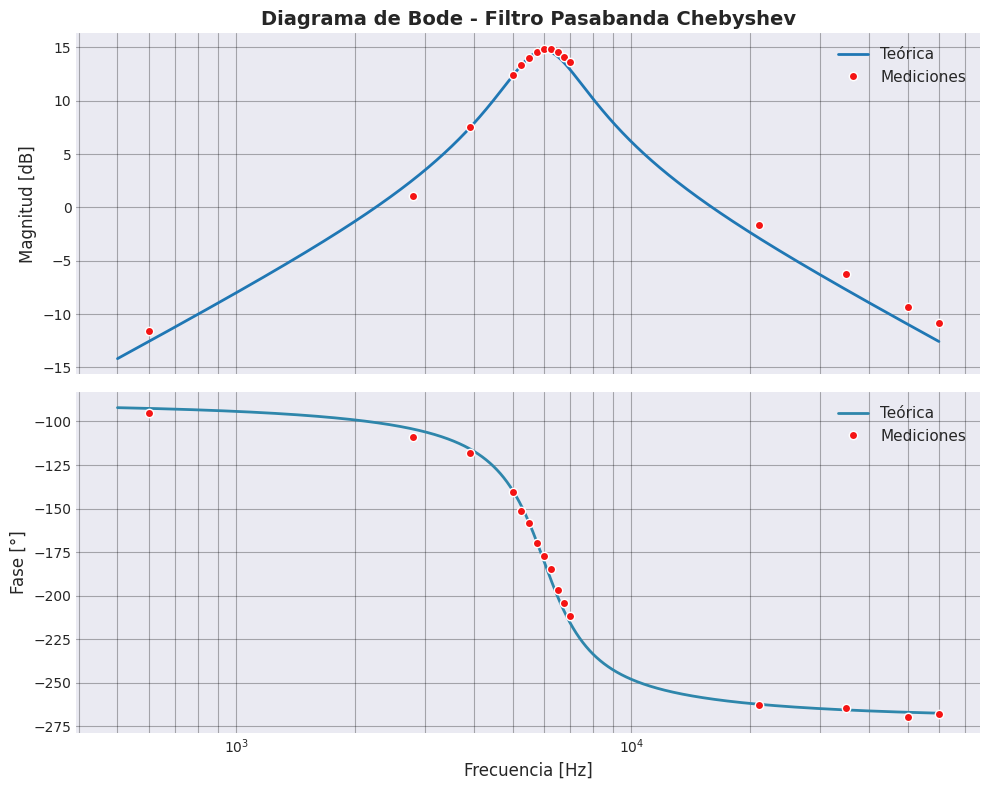

In [13]:
#MEDICIONES OSCILOCOPIO
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig

plt.style.use('seaborn-v0_8-darkgrid')

w0 = 6e3 * 2 * np.pi
Q_sos = 2.3328
k = -Q_sos**2

# Transferencia teorica de referencia
num = [k * w0 / Q_sos, 0]
den = [1, w0 / Q_sos, w0**2]
T_esperada = sig.TransferFunction(num, den)

w = np.logspace(np.log10(500 * 2 * np.pi), np.log10(60e3 * 2 * np.pi), 10000)
w, mag, phase = sig.bode(T_esperada, w)

# Mediciones tomadas en el laboratorio
f = np.array([600, 2800, 3900, 5000, 5250, 5500, 5750, 6000, 6250, 6500, 6750, 7000, 21e3, 35e3, 50e3, 60e3])
V_in = np.array([1.58, 1.63, 1.15, 1.62, 1.53, 1.44, 1.34, 1.25, 1.17, 1.13, 1.12, 1.10, 1.24, 1.25, 1.26, 1.26])
V_out = np.array([0.416, 1.85, 2.75, 6.78, 7.11, 7.23, 7.15, 6.88, 6.48, 6.05, 5.65, 5.3, 1.03, 0.61, 0.43, 0.362])
dt = np.array([440, 108, 84, 78, 80, 80, 82, 82, 82, 84, 84, 84, 34.8, 21, 15, 12.4]) * 1e-6

T_medida = 20 * np.log10(V_out / V_in)
fase_medida = f * dt * -360

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Grafico de Magnitud
ax1.plot(w / (2 * np.pi), mag, label='Teórica', linewidth=2)
ax1.plot(f, T_medida, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax1.set_ylabel('Magnitud [dB]', fontsize=12)
ax1.set_title('Diagrama de Bode - Filtro Pasabanda Chebyshev', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11, loc='best')
ax1.grid(True, which='both', color='black', alpha=0.3)
ax1.set_xscale('log')

# Grafico de Fase
ax2.plot(w / (2 * np.pi), phase, label='Teórica', linewidth=2, color='#2E86AB')
ax2.plot(f, fase_medida, 'o', label='Mediciones', markersize=6, color='#f51414', markeredgecolor='white', markeredgewidth=1)
ax2.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax2.set_ylabel('Fase [°]', fontsize=12)
ax2.legend(fontsize=11, loc='best')
ax2.grid(True, which='both', color='black', alpha=0.3)
ax2.set_xscale('log')

plt.tight_layout()
plt.show()

Al comparar las mediciones experimentales obtenidas mediante el osciloscopio con la curva teórica del diagrama de Bode, se observa un ajuste casi exacto tanto en magnitud como en fase a lo largo de toda la banda de frecuencias. Esto confirma el correcto funcionamiento del circuito implementado y valida el procedimiento de diseño empleado.

### ***Mediciones con el analizador de audio***

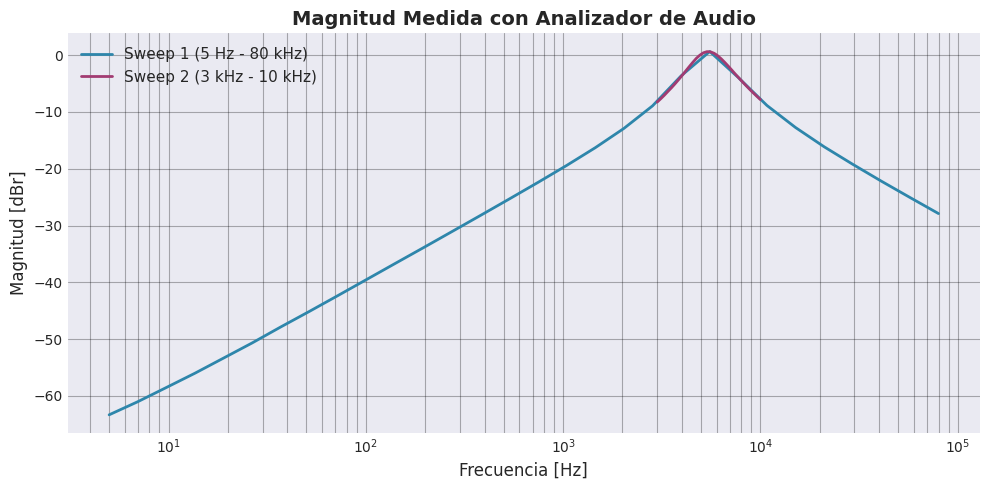

In [14]:
#MEDICIONES ANALIZADOR DE AUDIO

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

def leer_sweep(filename):
    with open(filename) as f:
        lines = f.readlines()
    f1_start = 3
    f1_end = next(i for i in range(f1_start, len(lines)) if lines[i].strip() == '')
    f1 = pd.read_csv(filename, skiprows=3, nrows=f1_end - f1_start - 1, names=['f_in', 'f_out'])
    f2_start = f1_end + 4
    f2 = pd.read_csv(filename, skiprows=f2_start, names=['f', 'dBr'])
    return f1, f2

_, sweep3 = leer_sweep('Sweep Data_3.csv')
_, sweep4 = leer_sweep('Sweep Data_4.csv')

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep3['f'], sweep3['dBr'], label='Sweep 1 (5 Hz - 80 kHz)', linewidth=2, color='#2E86AB')
ax.plot(sweep4['f'], sweep4['dBr'], label='Sweep 2 (3 kHz - 10 kHz)', linewidth=2, color='#A23B72')
ax.set_xscale('log')
ax.set_xlabel('Frecuencia [Hz]', fontsize=12)
ax.set_ylabel('Magnitud [dBr]', fontsize=12)
ax.set_title('Magnitud Medida con Analizador de Audio', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, which='both', color='black', alpha=0.3)
plt.tight_layout()
plt.show()

## ***Conclusión***

En este trabajo se abordó el desarrollo de un filtro pasabanda activo Chebyshev, partiendo de la transformación teórica y la obtención de la función de transferencia hasta su implementación en topología MFB. El diseño fue validado en simulación con LTSpice y corroborado experimentalmente en laboratorio mediante mediciones con osciloscopio y analizador de audio. La coincidencia entre los valores teóricos y los resultados medidos confirmó la correcta elección de componentes y el cumplimiento de todas las especificaciones de la plantilla.